# Pulse of Prevention:Analyzing Heart Health for Better Outcomes

## Objective
The primary challenge is to identify the key factors contributing to heart disease and to develop a profile of high-risk patients. This analysis will involve understanding patient demographics, medical history, and clinical measurements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv('/content/heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(302, 14)

In [10]:
df.reset_index(drop=True,inplace=True)

In [11]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
297,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
298,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
299,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
300,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0
301,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


### 1. BASIC

In [12]:
# 1.Average age of patients
print(df['age'].mean())

54.420529801324506


In [13]:
# 2.Gender distribution of patients
print(df['sex'].value_counts().rename({0:'Female',1:'Male'}))

sex
Male      206
Female     96
Name: count, dtype: int64


In [14]:
# 3.Average resting blood pressure
print(df['trestbps'].mean())

131.60264900662253


In [15]:
# 4.Patients have fasting blood sugar levels higher than 120 mg/dl
print(df[df['fbs']>120])

Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []


In [16]:
# 5.Different types of chest pain recorded in the dataset
print(df['cp'].unique())

[0 1 2 3]


In [17]:
# 6.Maximum heart rate achieved by patients
print(df['thalach'].max())

202


In [18]:
# 7.Percentage of patients experience exercise-induced angina
print(df['exang'].mean()*100)

32.78145695364238


In [19]:
# 8.Average cholesterol level in the dataset
print(df['chol'].mean())

246.5


In [20]:
# 9.No of Patients have a resting electrocardiographic result of 2
print(df['restecg'].value_counts()[2])

4


In [21]:
# 10.Distribution of the number of major vessels colored by fluoroscopy
print(df['ca'].value_counts())

ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64


### 2. MEDIUM

In [22]:
# 1.Correlation between age and cholesterol levels
print(df[['age','chol']].corr())

           age      chol
age   1.000000  0.207216
chol  0.207216  1.000000


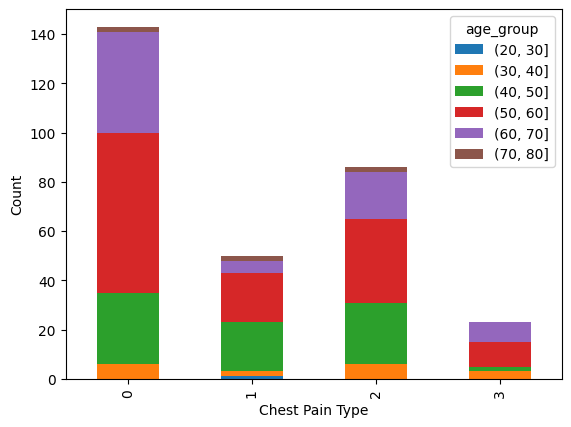

In [23]:
# 2.Distribution of chest pain types across different age groups
df['age_group'] = pd.cut(df['age'],bins=[20,30,40,50,60,70,80])
df.groupby('cp')['age_group'].value_counts().unstack().plot(kind='bar',stacked=True)
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

In [24]:
# 3.Maximum heart rate vary with exercise-induced angina
print(df.groupby('exang')['thalach'].mean().rename({0:'NO',1:'Yes'}))

exang
NO     155.596059
Yes    137.212121
Name: thalach, dtype: float64


In [25]:
# 4.Difference in resting blood pressure between male and female patients
print(df.groupby('sex')['trestbps'].mean().rename({0:'Female',1:'Male'}))

sex
Female    133.083333
Male      130.912621
Name: trestbps, dtype: float64


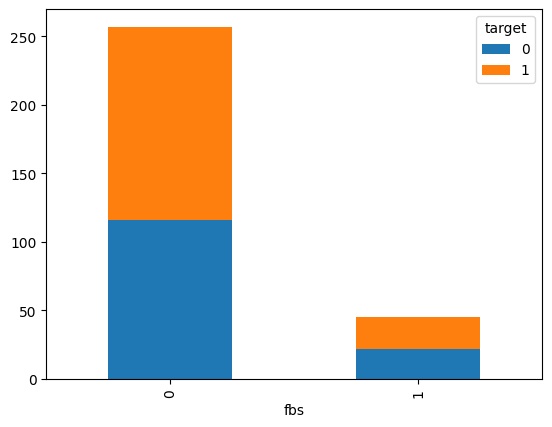

In [26]:
# 5.Relationship between fasting blood sugar levels and the presence of heart disease
pd.crosstab(df['fbs'],df['target']).plot(kind='bar',stacked=True)
plt.show()

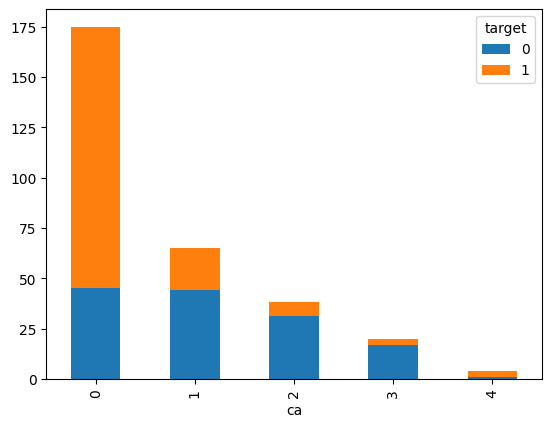

In [27]:
# 6.No of major vessels (ca) affect the target variable (heart disease presence)
pd.crosstab(df['ca'],df['target']).plot(kind='bar',stacked=True)
plt.show()

In [28]:
# 7.Average oldpeak value for patients with different types of chest pain
print(df.groupby('cp')['oldpeak'].mean())

cp
0    1.383217
1    0.316000
2    0.806977
3    1.391304
Name: oldpeak, dtype: float64


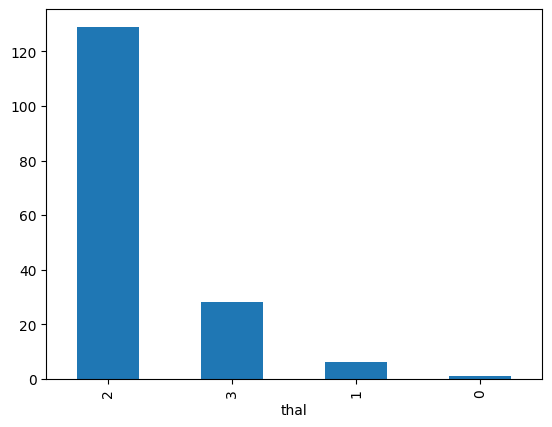

In [29]:
# 8.Distribution of thalassemia types (thal) among patients with heart disease
df[df['target']==1]['thal'].value_counts().plot(kind='bar')
plt.show()

In [30]:
# 9.Common combinations of risk factors in patients with heart disease
df[df['target']==1].groupby(['cp','fbs','exang','thal']).size().reset_index(name='count').sort_values('count',ascending=False)

,cp,fbs,exang,thal,count
15,2,0,0,2,41
8,1,0,0,2,30
1,0,0,0,2,23
19,2,1,0,2,10
4,0,0,1,2,6
16,2,0,0,3,6
23,3,0,0,2,5
9,1,0,0,3,4
17,2,0,1,2,4
20,2,1,0,3,3


In [31]:
# 10.Pairwise comparison of clinical measurements for patients with and without heart disease
df[df['target'] == 1].describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.0
mean,52.585366,0.560976,1.371951,129.250000,242.640244,0.140244,0.591463,158.378049,0.140244,0.586585,1.591463,0.341463,2.121951,1.0
std,9.511957,0.497788,0.953878,16.204739,53.456580,0.348303,0.505358,19.199080,0.348303,0.781734,0.594598,0.802137,0.467082,0.0
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,96.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,44.750000,0.000000,1.000000,120.000000,208.750000,0.000000,0.000000,148.750000,0.000000,0.000000,1.000000,0.000000,2.000000,1.0
50%,52.000000,1.000000,2.000000,130.000000,234.500000,0.000000,1.000000,161.000000,0.000000,0.200000,2.000000,0.000000,2.000000,1.0
75%,59.000000,1.000000,2.000000,140.000000,267.250000,0.000000,1.000000,172.000000,0.000000,1.025000,2.000000,0.000000,2.000000,1.0
max,76.000000,1.000000,3.000000,180.000000,564.000000,1.000000,2.000000,202.000000,1.000000,4.200000,2.000000,4.000000,3.000000,1.0


In [32]:
df[df['target'] == 0].describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.0
mean,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478,0.0
std,7.962082,0.380416,0.905920,18.729944,49.454614,0.367401,0.541321,22.598782,0.499232,1.300340,0.561324,1.043460,0.684762,0.0
min,35.000000,0.000000,0.000000,100.000000,131.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,52.000000,1.000000,0.000000,120.000000,217.250000,0.000000,0.000000,125.000000,0.000000,0.600000,1.000000,0.000000,2.000000,0.0
50%,58.000000,1.000000,0.000000,130.000000,249.000000,0.000000,0.000000,142.000000,1.000000,1.400000,1.000000,1.000000,3.000000,0.0
75%,62.000000,1.000000,0.000000,144.750000,283.000000,0.000000,1.000000,156.000000,1.000000,2.500000,1.750000,2.000000,3.000000,0.0
max,77.000000,1.000000,3.000000,200.000000,409.000000,1.000000,2.000000,195.000000,1.000000,6.200000,2.000000,4.000000,3.000000,0.0


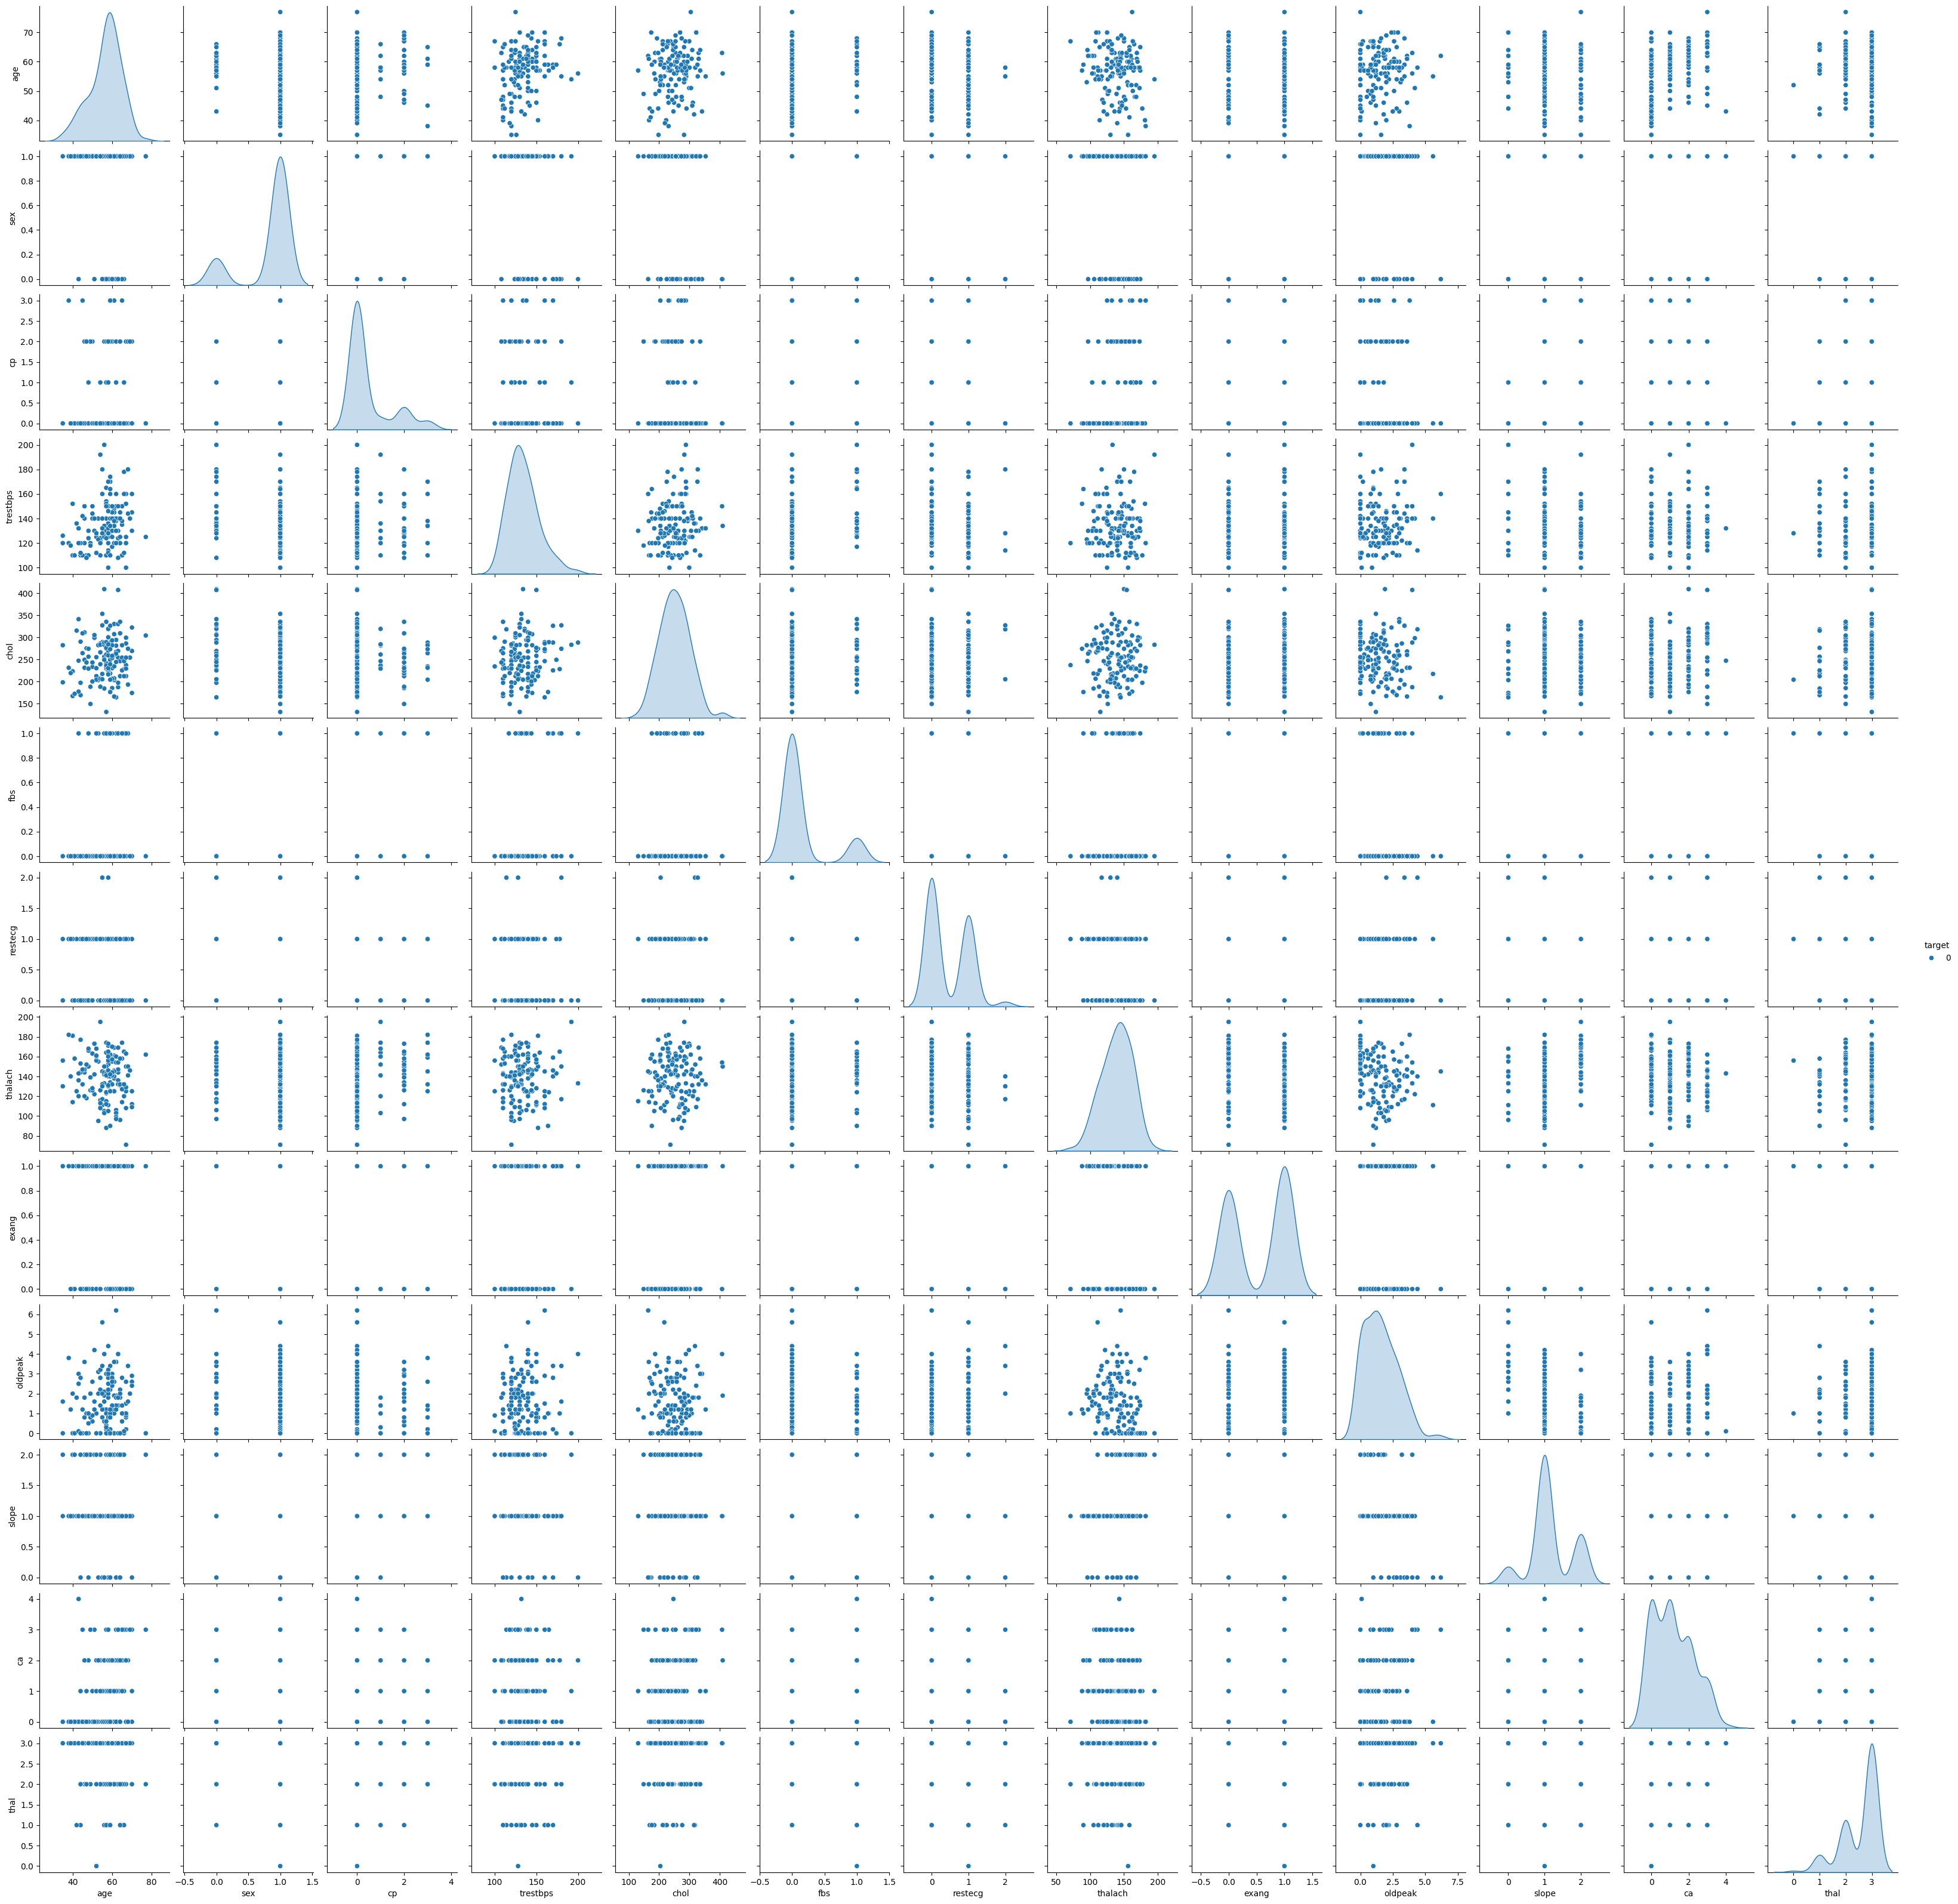

In [33]:
sns.pairplot(df[df['target'] == 0],hue='target')
plt.show()

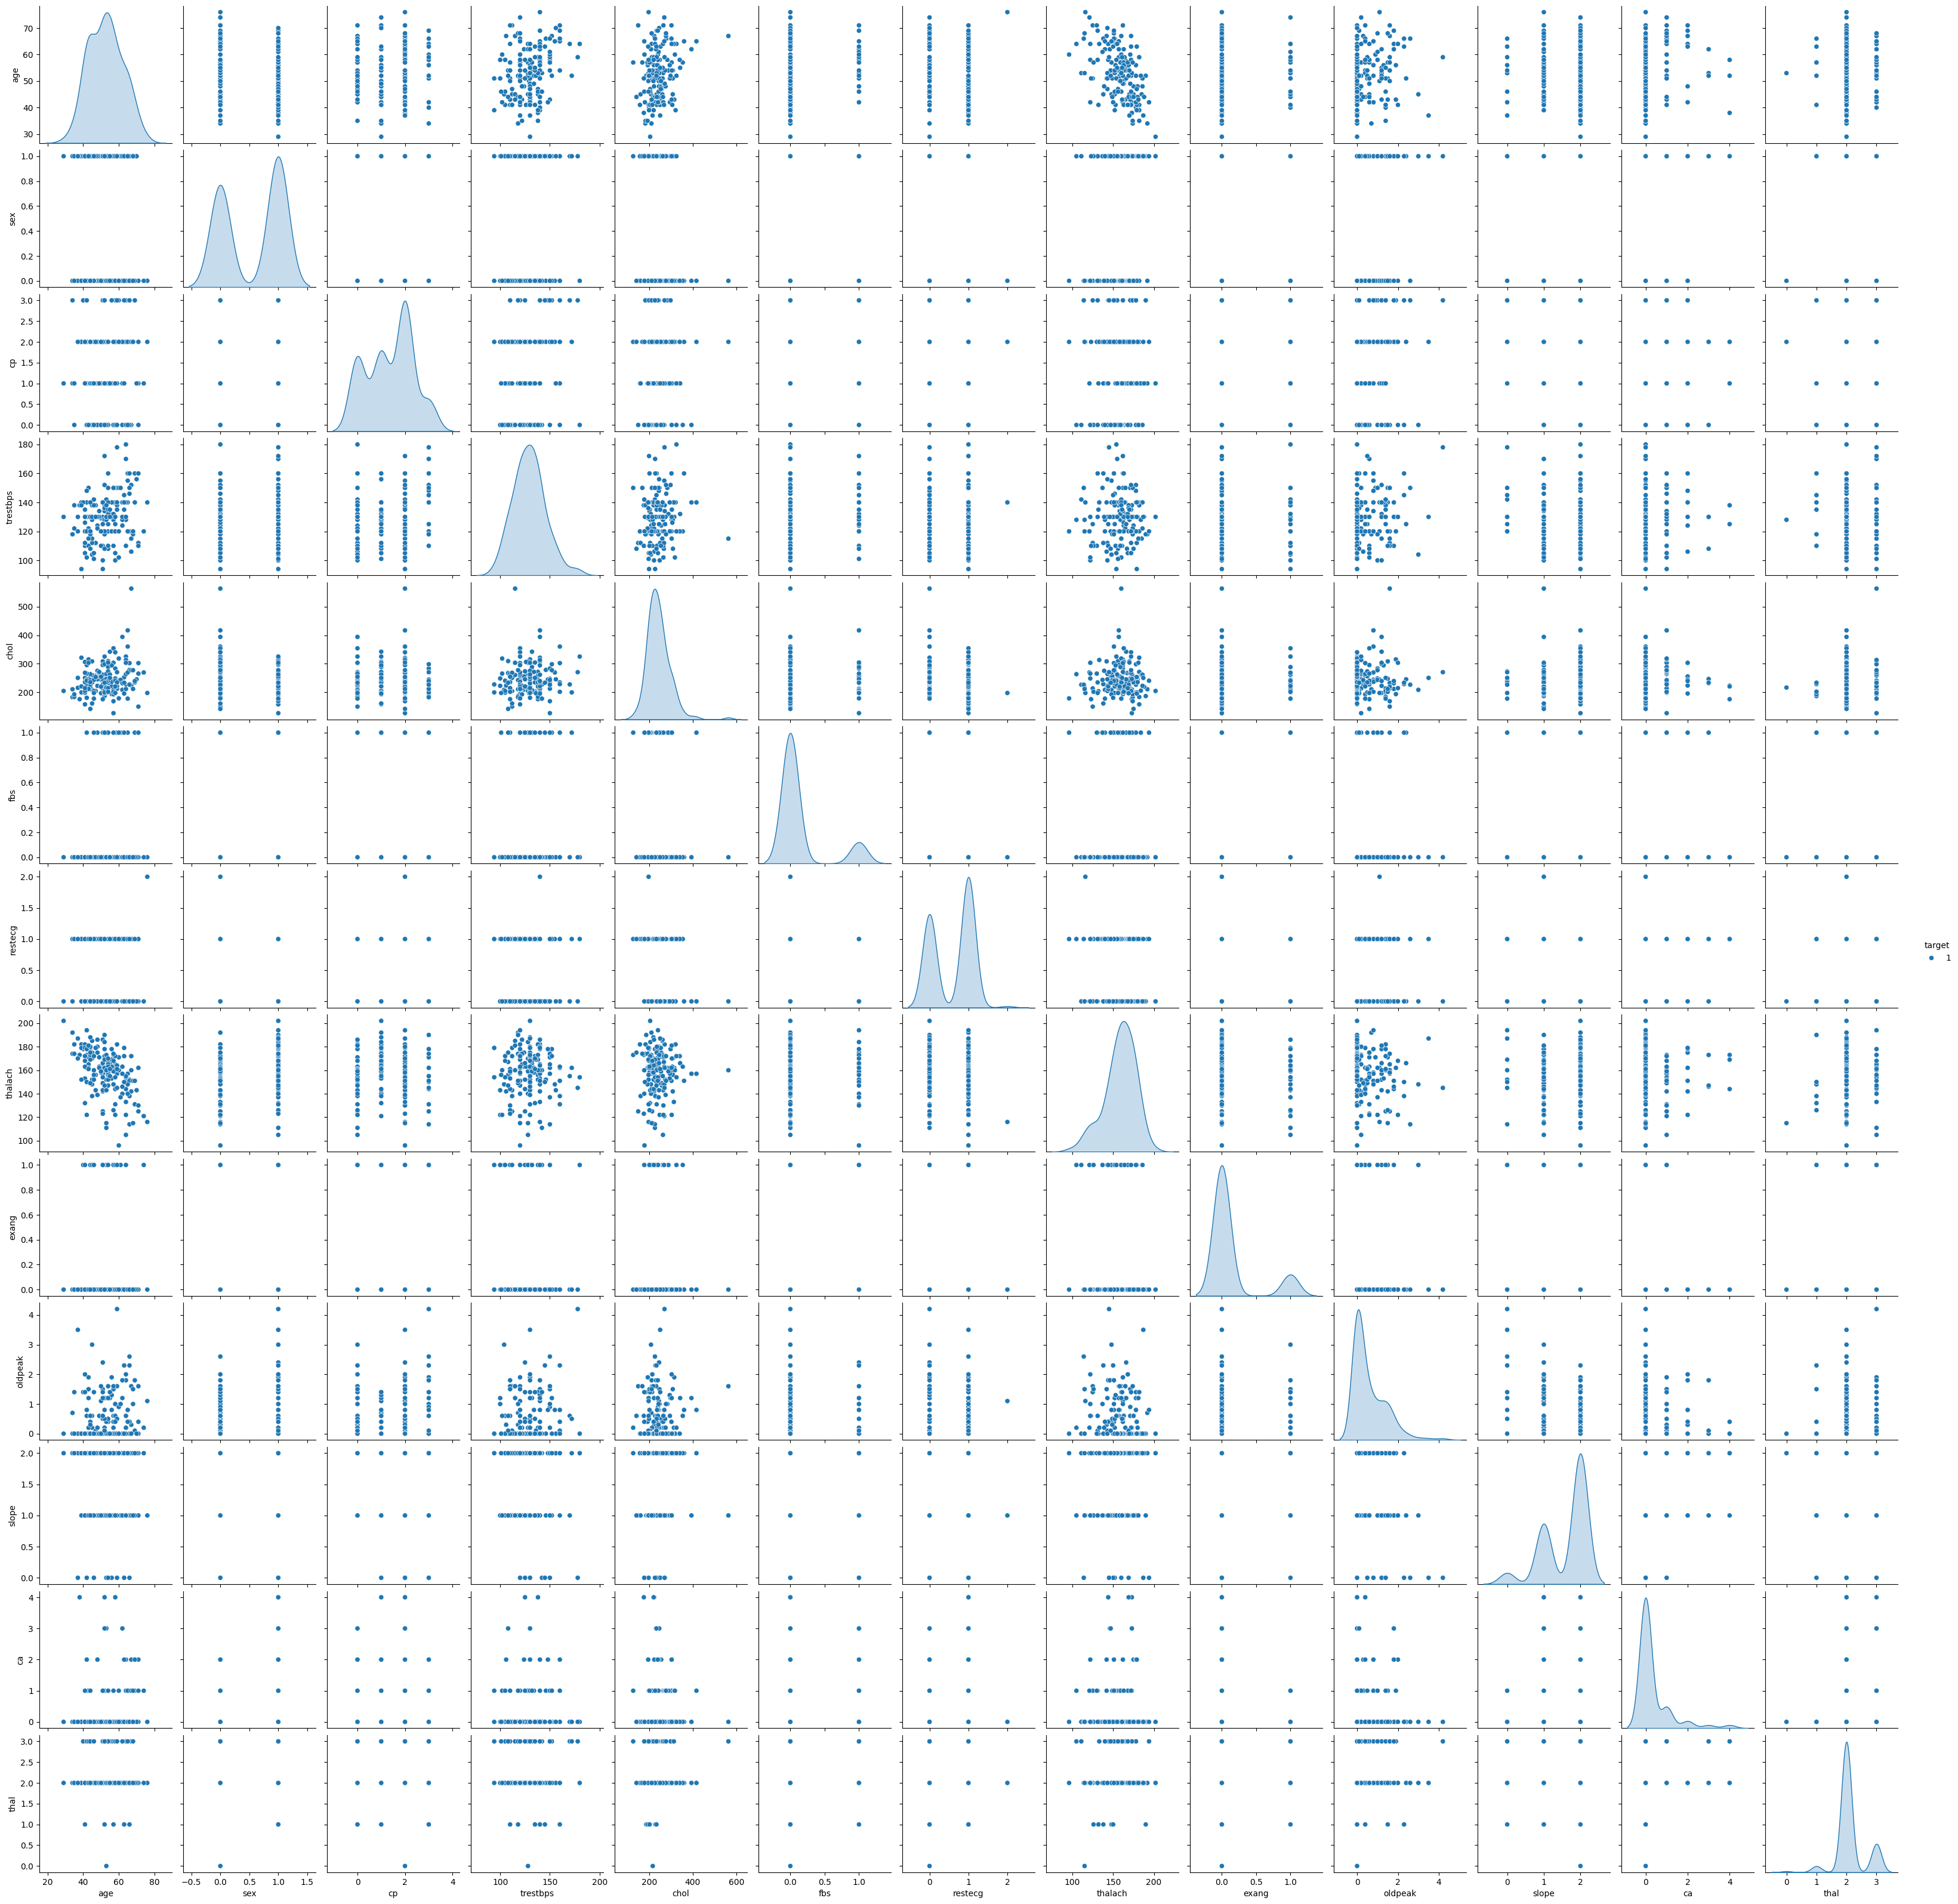

In [34]:
sns.pairplot(df[df['target'] == 1],hue='target')
plt.show()

### 3. ADVANCED

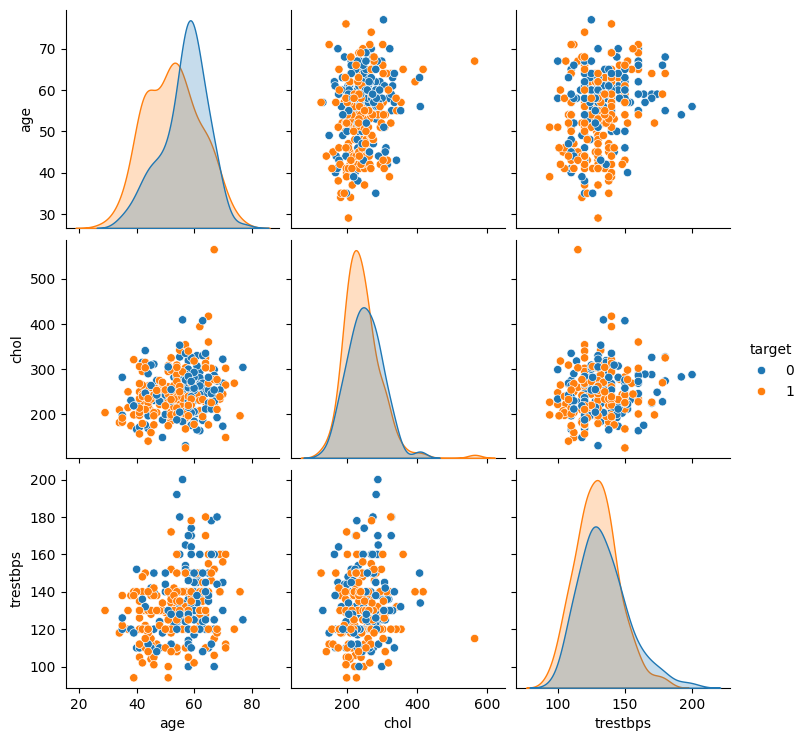

In [35]:
# 1.Effect of combining multiple risk factors
sns.pairplot(df,hue='target',vars=['age', 'chol', 'trestbps'])
plt.show()


In [36]:
# 2.Strongest correlation with heart disease presence
df.corr(numeric_only=True)['target'].sort_values(ascending=False)

,target
target,1.000000
cp,0.432080
thalach,0.419955
slope,0.343940
restecg,0.134874
fbs,-0.026826
chol,-0.081437
trestbps,-0.146269
age,-0.221476
sex,-0.283609


In [37]:
# 3.Slope of the peak exercise ST segment (slope) vary with different chest pain types
df.groupby('cp')['slope'].value_counts().unstack().plot(kind='bar',stacked=True)
plt.show()


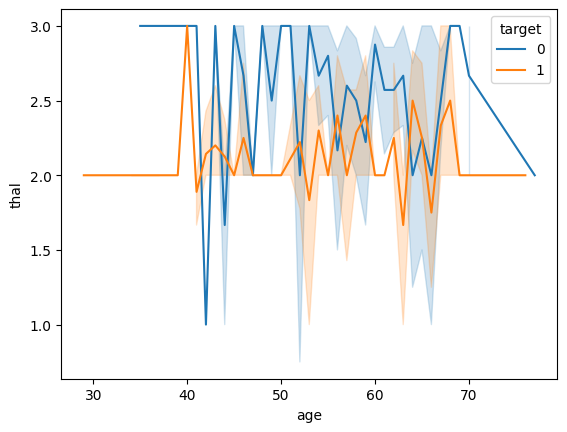

In [39]:
# 4.Survival rates of patients with different thalassemia types over a period
sns.lineplot(x='age', y='thal', hue='target', data=df)
plt.show()